# Step 4 analysis — market-sensitivity robustness of the required subsidy

This notebook analyzes the 108 market-sensitivity runs of the Step 4 batch
against their 18 Step 3 base cases. The 12 `large100_{sched}_{p05,p95}`
percentile runs from the same batch are analyzed in `step3_analysis` (they are
base-world runs, not sensitivities); this notebook reads only their QA exports
where a cross-reference helps.

Reporting follows the **layered robustness invariant** (issue 7, ratified
2026-08-12), in order of primacy:

1. **Bridge shape** (R2) — does the dual-decay shape survive each market world?
2. **Trajectory ranking** (R3) — does the ambition ladder's subsidy ordering survive?
3. **Subsidy level** (R4) — how far do the levels move?

R1 reads the binding structure first, because a sensitivity that unbinds a
mandate produces a zero dual ("this world needs no subsidy") — a first-class
finding that also decides which survival-matrix cells are defined at all.

Sensitivity arm semantics (encoded once in `SENS_META`; every label derives from it):
`gaslo` = `ngscen=AEO_2026_HOG` = high oil & gas **supply** = **low** gas price;
`gashi` = low supply = high gas price; `demhi` = EER2025 100%-by-2050
electrification load; `relo`/`rehi` = ATB-2024 advanced/conservative RE + storage
costs; `translim` = transmission-restricted (`transreg` + 1.07x long-term cap).

Duals come from the canonical QA exports (`step3_checks/exports/duals_by_year.csv`
for the base worlds, `step4_checks/exports/duals_by_year.csv` for the 120 new
runs), never re-derived — with a spot freshness check against the h5 files.

Run on the **playground-env** kernel. Requires drive D (freshness check only).

In [1]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import kendalltau

pd.set_option("display.width", 200)

HERE = Path.cwd()
assert HERE.name == "step4_analysis", f"run from z-ethan/step4_analysis/, not {HERE}"
REPO = HERE.parents[1]
EXPORTS = HERE / "exports"
FIGURES = HERE / "figures"
EXPORTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)
CHECKS3 = REPO / "z-ethan" / "step3_checks" / "exports"
CHECKS4 = REPO / "z-ethan" / "step4_checks" / "exports"
S3ANALYSIS = REPO / "z-ethan" / "step3_analysis" / "exports"

# all run outputs consolidated into one flat folder (drive reorganized 2026-08-18)
H5_DIR4 = Path("D:/ReEDS files/nuclear-learning/All runs so far")

# ---- case matrices ----------------------------------------------------------------
cases4 = pd.read_csv(REPO / "cases_nuclearlearning_step4.csv", index_col=0)
CASES4 = [c for c in cases4.columns if c != "Default Value"]
assert len(CASES4) == 120, len(CASES4)

SCHEDULES = ["eia", "aj", "iaea", "mck", "cop28", "eo"]      # ordered by 2050 ambition
SCHED_GW = {"eia": 117.3, "aj": 134.0, "iaea": 172.3, "mck": 200.0,
            "cop28": 300.0, "eo": 400.0}
SCHED_LABEL = {"eia": "EIA AEO high (117 GW)", "aj": "Abou-Jaoude (134 GW)",
               "iaea": "IAEA high (172 GW)", "mck": "McKinsey (200 GW)",
               "cop28": "COP28 (300 GW)", "eo": "2025 EO (400 GW)"}
PCTS = ["p05", "p50", "p95"]
SENS = ["gaslo", "gashi", "demhi", "relo", "rehi", "translim"]

# single source of truth for arm semantics — every figure label derives from this.
SENS_META = {
    "gaslo":    dict(label="Low gas price",  note="AEO_2026_HOG: high oil & gas supply = LOW price"),
    "gashi":    dict(label="High gas price", note="AEO_2026_LOG: low oil & gas supply = HIGH price"),
    "demhi":    dict(label="High-elec. load", note="EER2025 100%-by-2050 electrification demand"),
    "relo":     dict(label="Low RE cost",    note="ATB 2024 advanced RE + storage"),
    "rehi":     dict(label="High RE cost",   note="ATB 2024 conservative RE + storage"),
    "translim": dict(label="Transmission-limited", note="GSw_TransRestrict=transreg + 1.07x cap; "
                                                       "read national aggregates only (P7)"),
}

def parse_case(c):
    """Split a case name into (family, schedule, percentile, sensitivity)."""
    fam = "large" if c.startswith("large100") else "smr"
    parts = c.split("_")
    sens = parts[3] if len(parts) > 3 else ""
    return fam, parts[1], parts[2], sens

SENS_CASES = [c for c in CASES4 if parse_case(c)[3] in SENS]
assert len(SENS_CASES) == 108
BASE_CASES = [f"smr100_{tok}_{p}" for tok in SCHEDULES for p in PCTS]
BASE_OF = {c: "_".join(c.split("_")[:3]) for c in SENS_CASES}

# analysis paths: each of the 18 base cases plus its 6 sensitivity variants.
ALL_PATHS = BASE_CASES + SENS_CASES

print(f"paths: {len(ALL_PATHS)} = 18 base + 108 sensitivity")


paths: 126 = 18 base + 108 sensitivity


In [2]:
# ---- house figure style: z-ethan/plotstyle.py is the normative standard -----------
import sys

sys.path.insert(0, str(HERE.parent))
import plotstyle as ps

ps.apply()
COL = ps.COL
INK, MUTED, FAINT, GRID_C, EDGE_C, SURFACE = (ps.INK, ps.MUTED, ps.FAINT,
                                              ps.GRID_C, ps.EDGE_C, ps.SURFACE)
assert SCHEDULES == ps.SCHED_ORDER, "schedule tokens diverged from plotstyle.SCHED_ORDER"
SCHED_C = dict(ps.SCHED_C)
PCT_STYLE = dict(ps.PCT_STYLE)
SENS_C = dict(ps.SENS_C)
BASE_C = ps.BASE_C

def savefig(fig, name):
    return ps.savefig(fig, FIGURES / name)


## R0 — Data assembly and freshness

The dual table concatenates the two canonical QA exports.
Set-equality asserts guard the case coverage; a two-case re-derivation from the
h5 files guards freshness (same discipline as `step3_analysis`).

In [3]:
DUALS3 = pd.read_csv(CHECKS3 / "duals_by_year.csv")
DUALS4 = pd.read_csv(CHECKS4 / "duals_by_year.csv")
assert set(DUALS4["case"]) == set(CASES4)
assert set(BASE_CASES) <= set(DUALS3["case"])

DUALS = pd.concat([DUALS3[DUALS3["case"].isin(BASE_CASES)],
                   DUALS4[DUALS4["case"].isin(SENS_CASES)]], ignore_index=True)
assert set(DUALS["case"]) == set(ALL_PATHS)

fam, sched, pct, sens = zip(*[parse_case(c) for c in DUALS["case"]])
DUALS["schedule"], DUALS["pct"], DUALS["sens"] = sched, pct, sens
DUALS["sens"] = DUALS["sens"].replace("", "base")
DUALS["mandated"] = DUALS["mandate_MW"] > 0
DUALS["binding"] = DUALS["dual_2004_MWyr"] > 1.0          # QA convention
YEARS_RUN = sorted(DUALS["t"].unique())
assert len(YEARS_RUN) == 16, YEARS_RUN

OVB4 = pd.read_csv(CHECKS4 / "overbuild_by_case.csv")
OVB3 = pd.read_csv(CHECKS3 / "overbuild_by_case.csv")
OVB = pd.concat([OVB3[OVB3["case"].isin(BASE_CASES)],
                 OVB4[OVB4["case"].isin(SENS_CASES)]], ignore_index=True)

ARMS = ["base"] + SENS
print(DUALS.groupby("sens", sort=False)["case"].nunique().reindex(ARMS))


sens
base        18
gaslo       18
gashi       18
demhi       18
relo        18
rehi        18
translim    18
Name: case, dtype: int64


In [4]:
# ---- freshness spot test: the QA export matches the h5 files ----------------------
def h5_dual(path):
    with h5py.File(path, "r") as f:
        if "nuclear_cap_price" not in f:
            return pd.Series(dtype=float)
        g = f["nuclear_cap_price"]
        t = g["t"][:].astype(int)
        return pd.Series(g["Value"][:], index=t)

for c in ["smr100_eia_p50_gaslo", "smr100_eo_p95_translim"]:
    got = h5_dual(H5_DIR4 / f"step4_{c}_outputs.h5")
    exp = DUALS[(DUALS["case"] == c) & (DUALS["dual_2004_MWyr"] > 0)]         .set_index("t")["dual_2004_MWyr"]
    j = pd.concat([got, exp], axis=1, keys=["h5", "qa"]).fillna(0.0)
    assert float((j["h5"] - j["qa"]).abs().max()) < 1e-9, c
    print(f"fresh: {c} ({len(j)} dual years match the QA export)")


fresh: smr100_eia_p50_gaslo (5 dual years match the QA export)
fresh: smr100_eo_p95_translim (10 dual years match the QA export)


## R1 — Binding-structure shifts

Before any shape or level comparison: does the mandate still bind in each
market world? A case that a sensitivity **unbinds** (zero dual in every
mandated year) needs no subsidy in that world — a first-class finding, and its
survival-matrix cell is *undefined*, not "no decay".

In [5]:
# ---- s01: binding shifts vs base --------------------------------------------------
rows = []
for c in ALL_PATHS:
    _, tok, p, s = parse_case(c)
    s = s or "base"
    d = DUALS[(DUALS["case"] == c) & DUALS["mandated"]]
    byrs = sorted(d[d["binding"]]["t"])
    rows.append(dict(case=c, schedule=tok, pct=p, sens=s,
                     n_mandated=int(d["mandated"].sum()), n_binding=len(byrs),
                     binding_years=" ".join(map(str, byrs)),
                     max_overbuild=float(OVB.set_index("case").loc[c, "max_overbuild_ratio"])))
s01 = pd.DataFrame(rows)
base_nb = s01[s01.sens == "base"].set_index(["schedule", "pct"])["n_binding"]
base_by = s01[s01.sens == "base"].set_index(["schedule", "pct"])["binding_years"]
s01["d_n_binding"] = [
    int(r.n_binding - base_nb.loc[(r.schedule, r.pct)]) for r in s01.itertuples()]
s01["binding_set_changed"] = [
    r.binding_years != base_by.loc[(r.schedule, r.pct)] for r in s01.itertuples()]
s01.to_csv(EXPORTS / "s01_binding_shifts.csv", index=False)

unbound = s01[(s01.n_binding == 0) & (s01.sens != "base")]
print(f"unbound sensitivity cases: {len(unbound)}")
if len(unbound):
    print(unbound[["case", "schedule", "pct", "sens", "max_overbuild"]].to_string(index=False))
changed = s01[(s01.sens != "base") & s01.binding_set_changed]
print(f"cases whose binding-year set differs from base: {len(changed)} of 108")
print(s01[s01.sens != 'base'].groupby('sens')['d_n_binding']
      .agg(['mean', 'min', 'max']).round(2))


unbound sensitivity cases: 0
cases whose binding-year set differs from base: 19 of 108
          mean  min  max
sens                    
demhi    -0.67   -4    0
gashi    -1.56   -6    0
gaslo     0.06    0    1
rehi     -0.56   -3    0
relo      0.06    0    1
translim -0.22   -3    0


**Figure g01 — binding mandated years per case and market world.** Each cell
counts the mandated years whose dual exceeds $1/MW-yr (the QA binding
convention).

saved -> figures\g01_binding_heatmap.png


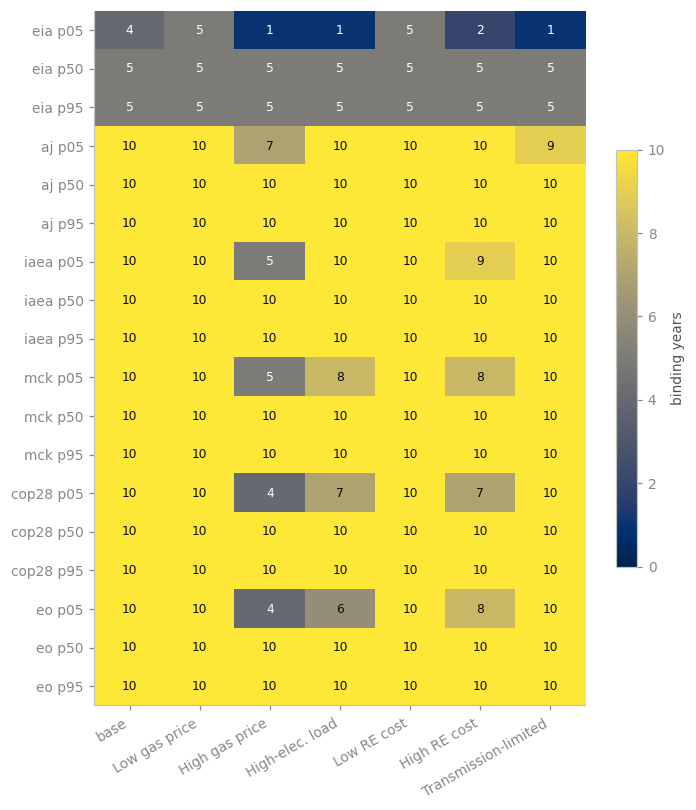

In [6]:
# ---- g01: binding-year-count heatmap (case x arm) ---------------------------------
CASE_ORDER = [(tok, p) for tok in SCHEDULES for p in PCTS]
M = np.full((len(CASE_ORDER), len(ARMS)), np.nan)
for i, (tok, p) in enumerate(CASE_ORDER):
    for j, s in enumerate(ARMS):
        row = s01[(s01.schedule == tok) & (s01.pct == p) & (s01.sens == s)]
        if len(row):
            M[i, j] = row.n_binding.iloc[0]

fig, ax = plt.subplots(figsize=(7.2, 8.2))
im = ax.imshow(M, cmap=ps.CMAP_SEQ, aspect="auto", vmin=0)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        v = M[i, j]
        ax.text(j, i, "-" if np.isnan(v) else f"{int(v)}", ha="center", va="center",
                fontsize=8, color="white" if v < np.nanmax(M) * 0.55 else INK)
ax.set_xticks(range(len(ARMS)))
ax.set_xticklabels(["base"] + [SENS_META[s]["label"] for s in SENS],
                   rotation=30, ha="right")
ax.set_yticks(range(len(CASE_ORDER)))
ax.set_yticklabels([f"{tok} {p}" for tok, p in CASE_ORDER])
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.6, label="binding years")
savefig(fig, "g01_binding_heatmap.png")
plt.show()


## R2 — PRIMARY: bridge-shape survival

The framing commitment's durable object is the **shape** of the dual
trajectory: a bridge subsidy should decay as the fleet walks down the learning
curve. Base-world finding (Step 3, S5): decay holds at p05, weakly and
unevenly at p50, and the p95 worlds do not come down by 2050.

Metrics per case are exactly `step3_analysis` t04's, for comparability:
`peak_year`, `end_over_peak`, `first_year_below_half_peak`,
`n_zero_dual_mandated_years`. The shape class is a notebook convention,
defined once here:

- **unbound** — no binding mandated year (see R1; cell undefined).
- **decays** — the dual falls below half its peak by 2050
  (`first_year_below_half_peak` is set, or the dual hits zero after the peak).
- **declines** — the 2050 dual sits below 0.95 x peak but never below half.
- **flat** — the 2050 dual is at or above 0.95 x peak (no meaningful decay).

Survival is judged on the class **and** on the continuous metric: a cell
"survives" if its class matches base or its `end_over_peak` moved by at most
0.15.

In [7]:
# ---- s02: shape metrics + survival ------------------------------------------------
def shape_metrics(c):
    d = DUALS[(DUALS["case"] == c) & DUALS["mandated"]].set_index("t").sort_index()
    b = d[d["binding"]]["dual_2004_MWyr"]
    if not len(b):
        return dict(peak_year=None, end_over_peak=None,
                    first_year_below_half_peak=None,
                    n_zero_dual_mandated_years=int((~d["binding"]).sum()),
                    n_binding=0, shape_class="unbound")
    peak_t, peak = int(b.idxmax()), float(b.max())
    end = float(d.loc[2050, "dual_2004_MWyr"]) if 2050 in d.index else 0.0
    below = [t for t in b.index if t > peak_t and b[t] < 0.5 * peak]
    zero_after = [t for t in d.index if t > peak_t and not d.loc[t, "binding"]]
    first_half = min(below + zero_after) if (below or zero_after) else None
    e = end / peak
    cls = "decays" if first_half is not None else ("flat" if e >= 0.95 else "declines")
    return dict(peak_year=peak_t, end_over_peak=round(e, 2),
                first_year_below_half_peak=first_half,
                n_zero_dual_mandated_years=int((~d["binding"]).sum()),
                n_binding=int(len(b)), shape_class=cls)

rows = []
for c in ALL_PATHS:
    _, tok, p, s = parse_case(c)
    rows.append(dict(case=c, schedule=tok, pct=p, sens=s or "base", **shape_metrics(c)))
s02 = pd.DataFrame(rows)

# regression tie: the base column must reproduce step3_analysis t04 exactly.
t04 = pd.read_csv(S3ANALYSIS / "t04_bridge_metrics.csv").set_index("case")
b02 = s02[s02.sens == "base"].set_index("case")
for c in BASE_CASES:
    assert abs(b02.loc[c, "end_over_peak"] - t04.loc[c, "end_over_peak"]) < 1e-9, c
    assert b02.loc[c, "peak_year"] == t04.loc[c, "peak_year"], c
    fh_b = b02.loc[c, "first_year_below_half_peak"]
    fh_t = t04.loc[c, "first_year_below_half_peak"]
    assert pd.isna(fh_b) == pd.isna(fh_t), c
    assert pd.isna(fh_b) or float(fh_b) == float(fh_t), c
    assert int(b02.loc[c, "n_zero_dual_mandated_years"]) == \
        int(t04.loc[c, "n_zero_dual_mandated_years"]), c
print("base shape metrics reproduce step3_analysis t04 exactly (18 cases, all four metrics)")

base_m = s02[s02.sens == "base"].set_index(["schedule", "pct"])
s02["base_class"] = [base_m.loc[(r.schedule, r.pct), "shape_class"] for r in s02.itertuples()]
s02["d_end_over_peak"] = [
    (r.end_over_peak - base_m.loc[(r.schedule, r.pct), "end_over_peak"])
    if (r.end_over_peak is not None
        and base_m.loc[(r.schedule, r.pct), "end_over_peak"] is not None) else None
    for r in s02.itertuples()]
s02["peak_year_shift"] = [
    (r.peak_year - base_m.loc[(r.schedule, r.pct), "peak_year"])
    if (r.peak_year is not None
        and pd.notna(base_m.loc[(r.schedule, r.pct), "peak_year"])) else None
    for r in s02.itertuples()]
s02["survives"] = [
    None if r.sens == "base" else
    ("undefined" if r.shape_class == "unbound" else
     ("yes" if (r.shape_class == r.base_class
                or (r.d_end_over_peak is not None and abs(r.d_end_over_peak) <= 0.15))
      else "no"))
    for r in s02.itertuples()]
s02.to_csv(EXPORTS / "s02_shape_survival.csv", index=False)

sv = s02[s02.sens != "base"]
print(sv.groupby("sens")["survives"].value_counts().unstack(fill_value=0))
print("\nclass transitions (base -> sens) that break survival:")
brk = sv[sv.survives == "no"]
print(brk.groupby(["base_class", "shape_class"])["case"].count() if len(brk)
      else "none")


base shape metrics reproduce step3_analysis t04 exactly (18 cases, all four metrics)
survives  yes
sens         
demhi      18
gashi      18
gaslo      18
rehi       18
relo       18
translim   18

class transitions (base -> sens) that break survival:
none


**Figure g02 (Fig 6 panel a) — bridge-shape survival matrix.** Each cell shows
the 2050 dual as a fraction of the peak dual; the glyph after the number is the
shape class (the key is annotated inside the figure, since it decodes the cell
text).

saved -> figures\g02_shape_survival_matrix.png


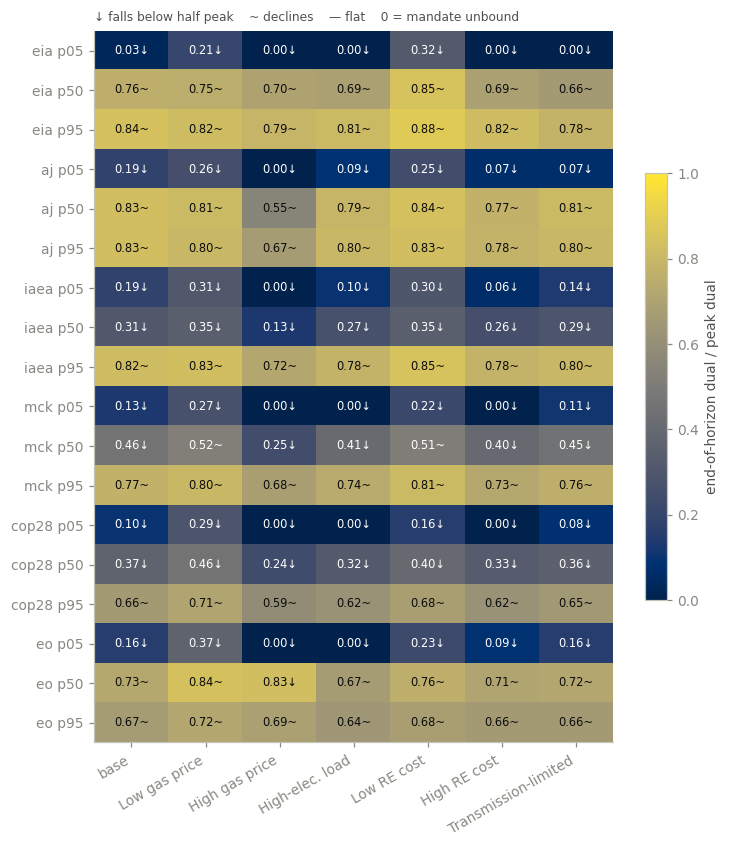

In [8]:
# ---- g02: survival matrix (Fig 6 panel a) -----------------------------------------
M = np.full((len(CASE_ORDER), len(ARMS)), np.nan)
CLS = np.empty((len(CASE_ORDER), len(ARMS)), dtype=object)
for i, (tok, p) in enumerate(CASE_ORDER):
    for j, s in enumerate(ARMS):
        row = s02[(s02.schedule == tok) & (s02.pct == p) & (s02.sens == s)]
        if len(row):
            CLS[i, j] = row.shape_class.iloc[0]
            if row.end_over_peak.iloc[0] is not None:
                M[i, j] = row.end_over_peak.iloc[0]

fig, ax = plt.subplots(figsize=(7.6, 8.4))
im = ax.imshow(M, cmap=ps.CMAP_SEQ, aspect="auto", vmin=0.0, vmax=1.0)
GLYPH = {"decays": "\u2193", "declines": "~", "flat": "\u2014", "unbound": ""}
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        if CLS[i, j] == "unbound":
            ax.text(j, i, "0", ha="center", va="center", fontsize=8, color=MUTED)
            continue
        v = M[i, j]
        # cividis: low values are dark blue (white text), high values light yellow (ink).
        ax.text(j, i, f"{v:.2f}{GLYPH[CLS[i, j]]}", ha="center", va="center",
                fontsize=7.5, color="white" if v < 0.55 else INK)
# glyph key must live in the saved figure — it decodes the cell text.
ax.text(0.0, 1.01, "\u2193 falls below half peak    ~ declines    \u2014 flat    "
        "0 = mandate not binding", transform=ax.transAxes,
        fontsize=8, color=MUTED, ha="left", va="bottom")
ax.set_xticks(range(len(ARMS)))
ax.set_xticklabels(["base"] + [SENS_META[s]["label"] for s in SENS],
                   rotation=30, ha="right")
ax.set_yticks(range(len(CASE_ORDER)))
ax.set_yticklabels([f"{ps.SCHED_SHORT[tok]}, {ps.PCT_SHORT[p]}" for tok, p in CASE_ORDER])
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.6, label="2050 shadow price ÷ peak shadow price")
savefig(fig, "g02_shape_survival_matrix.png")
plt.show()


**Figure g03 (Fig 6 panel b) — dual trajectories across market worlds at the
ladder ends (eia, eo).** Homogeneous 2x3 schedule-by-percentile grid: short
categorical panel labels only, no panel letters (house convention).

saved -> figures\g03_dual_overlays.png


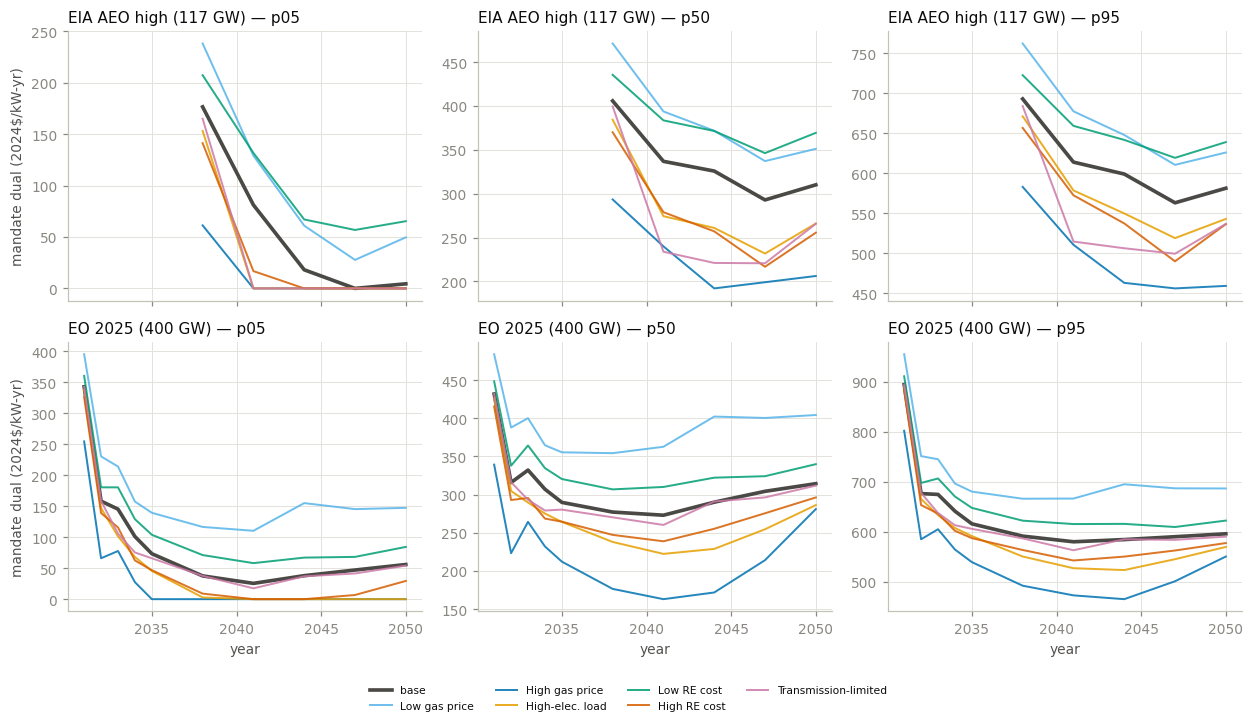

In [9]:
# ---- g03: dual-band overlays for the ladder ends (Fig 6 panel b) ------------------
fig, axes = plt.subplots(2, 3, figsize=(11.5, 6.4), sharex=True)
for row_i, tok in enumerate(["eia", "eo"]):
    for col_i, p in enumerate(PCTS):
        ax = axes[row_i, col_i]
        for s in ["base"] + SENS:
            c = f"smr100_{tok}_{p}" + ("" if s == "base" else f"_{s}")
            d = DUALS[(DUALS["case"] == c) & DUALS["mandated"]].set_index("t").sort_index()
            y = d["dual_2024_MWyr"] / 1000.0
            ax.plot(y.index, y.values,
                    color=BASE_C if s == "base" else SENS_C[s],
                    lw=2.4 if s == "base" else 1.3,
                    alpha=1.0 if s == "base" else 0.85,
                    label="base" if s == "base" else SENS_META[s]["label"])
        ax.set_title(f"{ps.SCHED_SHORT[tok]}, {ps.PCT_LABEL[p]}", fontsize=9)
        if col_i == 0:
            ax.set_ylabel("shadow price of the mandate (2024$/kW-yr)")
        if row_i == 1:
            ax.set_xlabel("year")
# figure-level legend below the grid: an in-axes legend occluded the start of
# the low-gas trace in the eia p05 panel (2026-08-17 audit)
h03, l03 = axes[0, 0].get_legend_handles_labels()
fig.legend(h03, l03, loc="lower center", ncol=4, fontsize=7,
           bbox_to_anchor=(0.5, -0.03))
fig.tight_layout(rect=(0, 0.04, 1, 1))
savefig(fig, "g03_dual_overlays.png")
plt.show()


## R3 — SECONDARY: ambition-ladder ranking preservation

Within each (market world, percentile), rank the six schedules by two subsidy
scalars: (a) the mean binding-year dual, and (b) a discounted program-bill
proxy, `sum_t dual_t x mandate_MW_t / DR^(t-2026)` (closer to the fiscal
object; robust to differing binding-year counts). Kendall's tau compares each
ordering against the base world's. With n = 6 the tau is coarse (15 pairs), so
the raw orderings and the pairwise swaps are exported alongside.

In [10]:
# ---- real discount rate (same derivation as step3_analysis) -----------------------
FIN_DIR = REPO / "inputs" / "financials"
sys_fin = pd.read_csv(FIN_DIR / "financials_sys_ATB2024.csv")
infl = pd.read_csv(FIN_DIR / "inflation_default.csv")
sys_fin = sys_fin.merge(infl, on="t", how="left")
sys_fin["d_nom"] = ((1 - sys_fin["debt_fraction"]) * (sys_fin["rroe_nom"] - 1)
                    + sys_fin["debt_fraction"] * (sys_fin["interest_rate_nom"] - 1)
                      * (1 - sys_fin["tax_rate"]) + 1)
sys_fin["d_real"] = sys_fin["d_nom"] / sys_fin["inflation_rate"]
dr_s = sys_fin.set_index("t")["d_real"].reindex(range(1990, 2051)).ffill()
DR = float(dr_s.loc[2010:2050].mean())
print(f"DR = {DR:.4f} (mean d_real, matching step3_analysis)")

# ---- s03: ranking preservation ----------------------------------------------------
def scalars(c):
    d = DUALS[(DUALS["case"] == c) & DUALS["mandated"]]
    b = d[d["binding"]]
    mean_dual = float(b["dual_2024_MWyr"].mean()) if len(b) else 0.0
    disc = (d["dual_2024_MWyr"] * d["mandate_MW"]
            / DR ** (d["t"] - 2026)).sum() / 1e9
    return mean_dual, float(disc)

SC = {c: scalars(c) for c in ALL_PATHS}
rows = []
for s in ARMS:
    for p in PCTS:
        for met_i, met in enumerate(["mean_binding_dual", "disc_program_bill"]):
            vals = {}
            for tok in SCHEDULES:
                c = f"smr100_{tok}_{p}" + ("" if s == "base" else f"_{s}")
                vals[tok] = SC[c][met_i]
            order = sorted(SCHEDULES, key=lambda k: vals[k])
            rows.append(dict(sens=s, pct=p, metric=met,
                             order_cheap_to_dear=" ".join(order),
                             **{f"v_{tok}": round(vals[tok], 3) for tok in SCHEDULES}))
s03 = pd.DataFrame(rows)

base_ord = s03[s03.sens == "base"].set_index(["pct", "metric"])["order_cheap_to_dear"]
taus, swaps = [], []
for r in s03.itertuples():
    bo = base_ord.loc[(r.pct, r.metric)].split()
    so = r.order_cheap_to_dear.split()
    tau = kendalltau([bo.index(t) for t in SCHEDULES],
                     [so.index(t) for t in SCHEDULES]).statistic
    sw = [(a, b) for i, a in enumerate(SCHEDULES) for b in SCHEDULES[i + 1:]
          if (bo.index(a) < bo.index(b)) != (so.index(a) < so.index(b))]
    taus.append(round(float(tau), 3))
    swaps.append("; ".join(f"{a}<->{b}" for a, b in sw) if sw else "")
s03["kendall_tau_vs_base"] = taus
s03["pairwise_swaps_vs_base"] = swaps
s03.to_csv(EXPORTS / "s03_ranking_preservation.csv", index=False)

sub = s03[s03.sens != "base"]
print(sub.groupby(["metric"])["kendall_tau_vs_base"].agg(["min", "mean"]).round(3))
print(f"\ncells with any swap: {(sub.pairwise_swaps_vs_base != '').sum()} of {len(sub)}")
print(sub[sub.pairwise_swaps_vs_base != ''][
    ["sens", "pct", "metric", "kendall_tau_vs_base", "pairwise_swaps_vs_base"]]
    .to_string(index=False))


DR = 1.0455 (mean d_real, matching step3_analysis)


                     min   mean
metric                         
disc_program_bill  0.867  0.993
mean_binding_dual  0.200  0.808

cells with any swap: 14 of 36
    sens pct            metric  kendall_tau_vs_base                                                pairwise_swaps_vs_base
   gaslo p05 mean_binding_dual                0.867                                                            cop28<->eo
   gaslo p50 mean_binding_dual                0.867                                                              eia<->eo
   gaslo p95 mean_binding_dual                0.867                                                             iaea<->eo
   gashi p05 mean_binding_dual                0.600                                  iaea<->cop28; iaea<->eo; mck<->cop28
   gashi p50 mean_binding_dual                0.867                                                              eia<->eo
   gashi p95 mean_binding_dual                0.733                                                   iaea<->

**Figure g04 — ambition-ladder subsidy ordering across market worlds.** Rank
of each schedule by mean binding dual (1 = cheapest), one panel per percentile;
panel labels are the percentile tokens.

saved -> figures\g04_ranking_bump.png


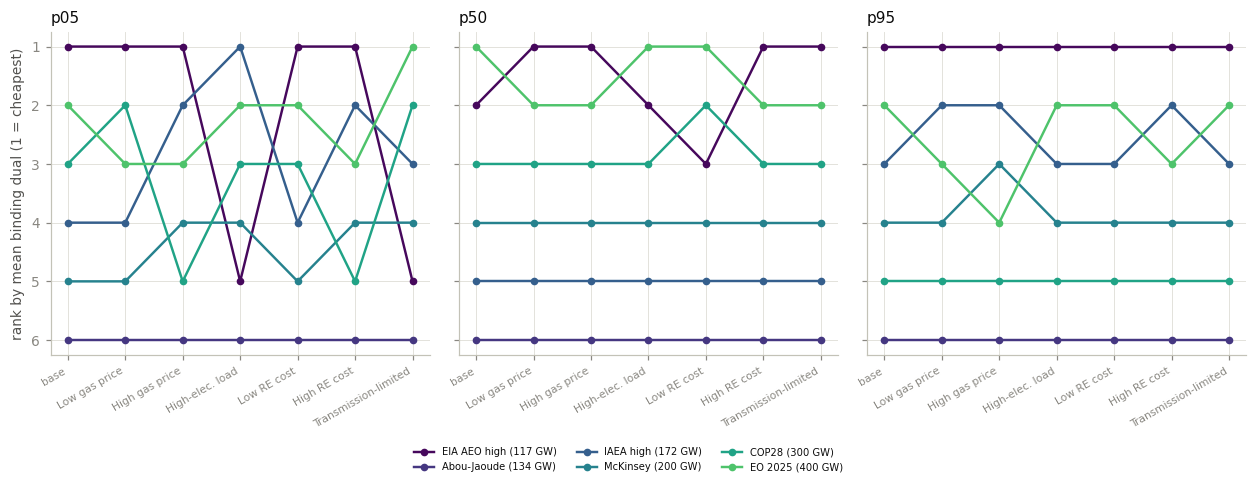

In [11]:
# ---- g04: bump chart of schedule ranks --------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(11.5, 4.2), sharey=True)
for ax, p in zip(axes, PCTS):
    for tok in SCHEDULES:
        ys = []
        for s in ARMS:
            o = s03[(s03.sens == s) & (s03.pct == p)
                    & (s03.metric == "mean_binding_dual")].order_cheap_to_dear.iloc[0].split()
            ys.append(o.index(tok) + 1)
        ax.plot(range(len(ARMS)), ys, marker="o", ms=4, color=SCHED_C[tok],
                lw=1.6, label=SCHED_LABEL[tok])
    ax.set_xticks(range(len(ARMS)))
    ax.set_xticklabels(["base"] + [SENS_META[s]["label"] for s in SENS],
                       rotation=30, ha="right", fontsize=7)
    ax.set_title(p)
    ax.invert_yaxis()
    ax.set_yticks(range(1, 7))
axes[0].set_ylabel("rank by mean binding dual (1 = cheapest)")
# figure-level legend below: the in-axes legend sat on the flat rank-6 line
# in the p05 panel (2026-08-17 audit)
h04, l04 = axes[0].get_legend_handles_labels()
fig.legend(h04, l04, loc="lower center", ncol=3, fontsize=6.5,
           bbox_to_anchor=(0.5, -0.05))
fig.tight_layout(rect=(0, 0.03, 1, 1))
savefig(fig, "g04_ranking_bump.png")
plt.show()


## R4 — TERTIARY: subsidy-level shifts

Per case: the ratio of the mean dual against base over the **intersection** of
binding years (like-for-like; the headline), with the each-on-own-binding-years
ratio as a companion column. An empty intersection cross-references R1.

**No per-sensitivity ITC-rate recompute** (decision 2026-08-15): the nuclear
financing inputs of every sensitivity case are byte-identical to its base case
(step4_checks B1), so for a given case-year the S8 translation chain
(fin_mult inversion → monetized m → i_model) is a fixed linear map in the
dual — required-rate shifts follow the dual ratios below up to binding-year-set
changes, which R1 reports. Levels are the weakest layer of the invariant and
M5 makes no rate claim. All level readouts are national; `translim` regional
detail is out of scope (the P7 siting-degeneracy caveat).

In [12]:
# ---- s04: level ratios vs base ----------------------------------------------------
rows = []
for c in SENS_CASES:
    _, tok, p, s = parse_case(c)
    b = BASE_OF[c]
    dc = DUALS[(DUALS["case"] == c) & DUALS["binding"]].set_index("t")["dual_2024_MWyr"]
    db = DUALS[(DUALS["case"] == b) & DUALS["binding"]].set_index("t")["dual_2024_MWyr"]
    inter = sorted(set(dc.index) & set(db.index))
    rows.append(dict(
        case=c, schedule=tok, pct=p, sens=s, n_shared_binding=len(inter),
        ratio_shared=round(float(dc.reindex(inter).mean() / db.reindex(inter).mean()), 3)
        if inter else None,
        ratio_own=round(float(dc.mean() / db.mean()), 3)
        if len(dc) and len(db) else None))
s04 = pd.DataFrame(rows)
s04.to_csv(EXPORTS / "s04_level_ratios.csv", index=False)

print(s04.groupby("sens")["ratio_shared"]
      .agg(["count", "min", "median", "max"]).round(3).reindex(SENS))
empty = s04[s04.n_shared_binding == 0]
if len(empty):
    print(f"\nempty binding-year intersection (see R1): {list(empty.case)}")


          count    min  median    max
sens                                 
gaslo        18  1.090   1.182  1.768
gashi        18  0.347   0.725  0.866
demhi        18  0.772   0.916  0.965
relo         18  1.043   1.092  1.682
rehi         18  0.613   0.905  0.956
translim     18  0.802   0.948  0.984


**Figure g05 — subsidy-level shift by market world.** One dot per case: the
mean binding dual relative to base over the shared binding years; the marker
shape encodes the percentile and the ink bar marks the arm median (legend
in-figure). Dotted line = no shift.

saved -> figures\g05_level_ratios.png


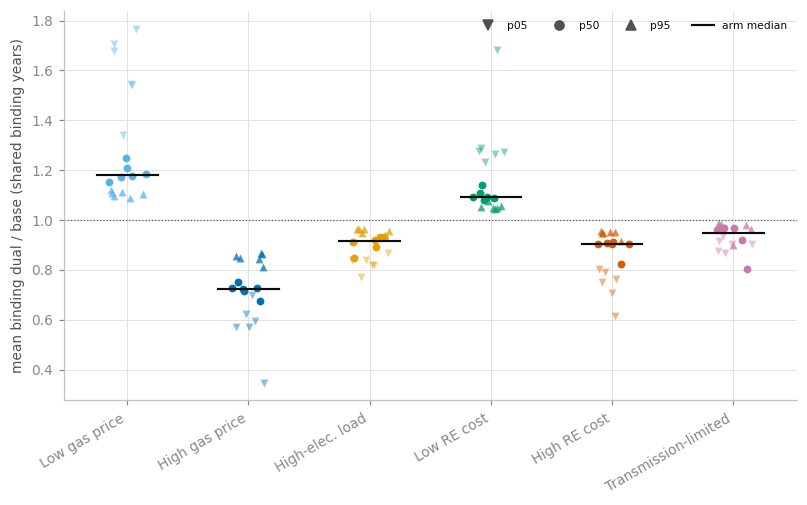

In [13]:
# ---- g05: level-ratio dot plot ----------------------------------------------------
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(8.6, 4.6))
rng = np.random.default_rng(20260715)
for j, s in enumerate(SENS):
    sub = s04[(s04.sens == s) & s04.ratio_shared.notna()]
    x = j + rng.uniform(-0.16, 0.16, len(sub))
    for (xi, r) in zip(x, sub.itertuples()):
        ax.scatter(xi, r.ratio_shared, s=26, color=SENS_C[s],
                   alpha={"p05": 0.45, "p50": 1.0, "p95": 0.75}[r.pct],
                   marker={"p05": "v", "p50": "o", "p95": "^"}[r.pct], lw=0)
    med = sub.ratio_shared.median()
    ax.plot([j - 0.25, j + 0.25], [med, med], color=INK, lw=1.4)
ax.axhline(1.0, color=MUTED, lw=0.8, ls=":")
ax.set_xticks(range(len(SENS)))
ax.set_xticklabels([SENS_META[s]["label"] for s in SENS], rotation=30, ha="right")
ax.set_ylabel("mean binding dual / base (shared binding years)")
# marker key must live in the saved figure — it decodes the dot shapes.
handles = ([Line2D([], [], marker=m, ls="", color=MUTED, label=p)
            for p, m in [("p05", "v"), ("p50", "o"), ("p95", "^")]]
           + [Line2D([], [], color=INK, lw=1.4, label="arm median")])
ax.legend(handles=handles, fontsize=7, ncol=4, loc="best")
savefig(fig, "g05_level_ratios.png")
plt.show()


## R5 — Mechanism color (context only)

Directional sanity of the level shifts against economic priors. The mandate
fixes the nuclear build, so the dual moves with the *market value* of the
mandated capacity: anything that lowers energy/capacity prices (cheap gas,
cheap RE) should raise the required subsidy; anything that raises them (dear
gas, dear RE, high electrification demand) should lower it. Transmission
limits cut both ways (local scarcity vs. delivery constraints) — no prior.
Surprises here are flagged for the M5 text, not adjudicated.

In [14]:
PRIOR = {"gaslo": ">1", "gashi": "<1", "demhi": "<1",
         "relo": ">1", "rehi": "<1", "translim": "none"}
rows = []
for s in SENS:
    sub = s04[(s04.sens == s) & s04.ratio_shared.notna()]
    frac_up = float((sub.ratio_shared > 1.0).mean())
    med = float(sub.ratio_shared.median())
    pr = PRIOR[s]
    if pr == "none":
        verdict = "no prior"
    else:
        agrees = (med > 1.0) if pr == ">1" else (med < 1.0)
        verdict = "agrees" if agrees else "SURPRISE"
    rows.append(dict(sens=s, prior=pr, median_ratio=round(med, 3),
                     frac_cases_above_1=round(frac_up, 2), verdict=verdict))
r5 = pd.DataFrame(rows)
print(r5.to_string(index=False))
r5.to_csv(EXPORTS / "s05_mechanism_color.csv", index=False)


    sens prior  median_ratio  frac_cases_above_1  verdict
   gaslo    >1         1.181                 1.0   agrees
   gashi    <1         0.725                 0.0   agrees
   demhi    <1         0.916                 0.0   agrees
    relo    >1         1.091                 1.0   agrees
    rehi    <1         0.905                 0.0   agrees
translim  none         0.948                 0.0 no prior


## R6 — Caveats and output manifest

- **P7 siting degeneracy:** regional and transmission readouts across cost
  worlds are not interpretable case-to-case; every number in this notebook is
  national. This binds hardest for `translim`.
- **Sequential myopia:** all runs are sequential/myopic; the duals are per-year
  rental prices. The foresight-vs-myopia wedge stays analytical
  (`step3_analysis` t11) — the intertemporal arm was cancelled (the solver has
  not worked for years, per NREL 2026-08-13).
- **Cross-schedule levels conflate cost worlds:** each schedule's percentile
  cases are different drawn worlds; cross-schedule level comparisons are
  descriptive, not causal (same framing as `step3_analysis`).
- **Unbound cells:** a zero-dual world is "needs no subsidy", not "no decay";
  survival-matrix cells for unbound cases are undefined by construction.
- **Shape-class thresholds** (0.5 x peak; 0.95 flat cut; 0.15 survival band)
  are notebook conventions, stated in R2 and exported with the data so any
  reader can re-cut them.

In [15]:
manifest = sorted(p.name for p in EXPORTS.glob("s0*.csv")) \
    + sorted(p.name for p in FIGURES.glob("g0*.png"))
print("outputs written by this notebook:")
for m in manifest:
    print(" ", m)


outputs written by this notebook:
  s01_binding_shifts.csv
  s02_shape_survival.csv
  s03_ranking_preservation.csv
  s04_level_ratios.csv
  s05_mechanism_color.csv
  g01_binding_heatmap.png
  g02_shape_survival_matrix.png
  g03_dual_overlays.png
  g04_ranking_bump.png
  g05_level_ratios.png
